In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import io
import requests

In [2]:
url = "https://esploradati.istat.it/SDMXWS/rest/data/41_983"
headers={'Accept': 'application/vnd.sdmx.data+csv;version=1.0.0'}

In [4]:
r = requests.get(url, headers=headers, timeout=60) 
#manda la richiesta una volta al giorno e basta
# usa headers=headers
# timeout per non farlo andare all'infinito

ReadTimeout: HTTPSConnectionPool(host='esploradati.istat.it', port=443): Read timed out. (read timeout=60)

In [6]:
type(r)

requests.models.Response

In [11]:
r.status_code

500

In [8]:
print(r.text)

Error during writing responce


In [ ]:
r = r.content
rawData = pd.read_csv(io.StringIO(r.decode('utf-8')))  #per trasformare il csv preso con api in una tabella

In [15]:
rawData.head(5)



,Error during writing responce


In [163]:
rawData.info()

<class 'pandas.DataFrame'>
RangeIndex: 573552 entries, 0 to 573551
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATAFLOW          573552 non-null  str    
 1   FREQ              573552 non-null  str    
 2   REF_AREA          573552 non-null  int64  
 3   DATA_TYPE         573552 non-null  str    
 4   RESULT            573552 non-null  str    
 5   TIME_PERIOD       573552 non-null  int64  
 6   OBS_VALUE         573552 non-null  int64  
 7   OBS_STATUS        0 non-null       float64
 8   NOTE_DS           0 non-null       float64
 9   NOTE_REF_AREA     0 non-null       float64
 10  NOTE_DATA_TYPE    0 non-null       float64
 11  NOTE_RESULT       0 non-null       float64
 12  NOTE_TIME_PERIOD  0 non-null       float64
 13  BASE_PER          0 non-null       float64
 14  UNIT_MEAS         0 non-null       float64
 15  UNIT_MULT         0 non-null       float64
dtypes: float64(9), int64(3), str(4)

In [164]:
rawData["DATA_TYPE"].unique() 
#le voci distinte in DATA_TYPE, 
#KILLINJ indica il numero di persone che o sono morte (colonna M di result) o sono state ferite (colonna F di result)
#ROADACC fa vedere il numero totale di incidenti, la colonna result in questo caso non ha valore

<StringArray>
['KILLINJ', 'ROADACC']
Length: 2, dtype: str

In [165]:
print(rawData["RESULT"].unique())
print(rawData["FREQ"].unique())

<StringArray>
['F', 'M', '9']
Length: 3, dtype: str
<StringArray>
['A']
Length: 1, dtype: str


In [ ]:
rawData = rawData.drop(["OBS_STATUS"], axis = 1)
rawData = rawData.drop(["NOTE_DS"], axis = 1)
rawData = rawData.drop(["NOTE_REF_AREA"], axis = 1)
rawData = rawData.drop(["NOTE_DATA_TYPE"], axis = 1)
rawData = rawData.drop(["NOTE_RESULT"], axis = 1)
rawData = rawData.drop(["NOTE_TIME_PERIOD"], axis = 1)
rawData = rawData.drop(["BASE_PER"], axis = 1)
rawData = rawData.drop(["UNIT_MEAS"], axis = 1)
rawData = rawData.drop(["UNIT_MULT"], axis = 1) 
#togliamo tutte le colonne NULL che tanto non ci servono
#axis = 1 perché si tratta di una colonna e non una riga

In [167]:
rawData = rawData.drop(["FREQ"], axis = 1) 
#questa pure la togliamo in quanto contiene solo la lettera A

In [168]:
rawData.head()

,DATAFLOW,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE
0,IT1:41_983(1.0),1001,KILLINJ,F,2001,10
1,IT1:41_983(1.0),1001,KILLINJ,F,2002,10
2,IT1:41_983(1.0),1001,KILLINJ,F,2003,7
3,IT1:41_983(1.0),1001,KILLINJ,F,2004,13
4,IT1:41_983(1.0),1001,KILLINJ,F,2005,2


In [169]:
rawData["OBS_VALUE"].describe()
#qua si nota una possibile presenza di outliers

count    573552.000000
mean         20.207603
std         245.813966
min           0.000000
25%           0.000000
50%           1.000000
75%           8.000000
max       30254.000000
Name: OBS_VALUE, dtype: float64

In [170]:
rawData.sort_values("OBS_VALUE", ascending= False).head(10)

,DATAFLOW,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE
348588,IT1:41_983(1.0),58091,KILLINJ,F,2004,30254
348589,IT1:41_983(1.0),58091,KILLINJ,F,2005,28653
348590,IT1:41_983(1.0),58091,KILLINJ,F,2006,28209
348585,IT1:41_983(1.0),58091,KILLINJ,F,2001,27865
348586,IT1:41_983(1.0),58091,KILLINJ,F,2002,26696
348587,IT1:41_983(1.0),58091,KILLINJ,F,2003,26638
348591,IT1:41_983(1.0),58091,KILLINJ,F,2007,26299
128817,IT1:41_983(1.0),15146,KILLINJ,F,2001,24858
348593,IT1:41_983(1.0),58091,KILLINJ,F,2009,24638
128818,IT1:41_983(1.0),15146,KILLINJ,F,2002,24487


In [ ]:
rawData[rawData["DATA_TYPE"]== "ROADACC"].sort_values("OBS_VALUE", ascending= False).head(15)
#qui volevo controllare se c'erano anomalie solo sul numero di incidenti

,DATAFLOW,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE
348636,IT1:41_983(1.0),58091,ROADACC,9,2004,23135
348633,IT1:41_983(1.0),58091,ROADACC,9,2001,22220
348637,IT1:41_983(1.0),58091,ROADACC,9,2005,21902
348638,IT1:41_983(1.0),58091,ROADACC,9,2006,21452
348634,IT1:41_983(1.0),58091,ROADACC,9,2002,21330
348635,IT1:41_983(1.0),58091,ROADACC,9,2003,20426
348639,IT1:41_983(1.0),58091,ROADACC,9,2007,19960
348641,IT1:41_983(1.0),58091,ROADACC,9,2009,18561
348642,IT1:41_983(1.0),58091,ROADACC,9,2010,18496
348643,IT1:41_983(1.0),58091,ROADACC,9,2011,18235


In [ ]:
towns = pd.read_csv("Comuni.csv", sep=';')
towns.head(10)
#per questo dataset ho scaricarato direttamente il csv invece che fare web scraping

,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),Codice Comune (numerico),Comune,Comune (dizione straniera),Sigla automobilistica,Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente)
0,1,1,1,201,1001,1001,Agliè,NaN,TO,0,0,2644,2011,"13,1462",2020,2545,2020
1,1,1,1,201,1002,1002,Airasca,NaN,TO,0,0,3819,2011,"15,7393",2020,3633,2020
2,1,1,1,201,1003,1003,Ala di Stura,NaN,TO,0,0,462,2011,"46,3315",2020,459,2020
3,1,1,1,201,1004,1004,Albiano d'Ivrea,NaN,TO,0,0,1791,2011,"11,7314",2020,1638,2020
4,1,1,1,201,1006,1006,Almese,NaN,TO,0,0,6303,2011,"17,8756",2020,6355,2020
5,1,1,1,201,1007,1007,Alpette,NaN,TO,0,0,277,2011,"5,6261",2020,235,2020
6,1,1,1,201,1008,1008,Alpignano,NaN,TO,0,0,16893,2011,"11,9193",2020,16484,2020
7,1,1,1,201,1009,1009,Andezeno,NaN,TO,0,0,1966,2011,"7,4860",2020,2013,2020
8,1,1,1,201,1010,1010,Andrate,NaN,TO,0,0,512,2011,"9,3085",2020,488,2020
9,1,1,1,201,1011,1011,Angrogna,NaN,TO,0,0,870,2011,"38,8782",2020,838,2020


In [173]:
towns.info()

<class 'pandas.DataFrame'>
RangeIndex: 7903 entries, 0 to 7902
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Codice Ripartizione geografica  7903 non-null   int64
 1   Codice Regione                  7903 non-null   int64
 2   Codice Provincia (Storico)      7903 non-null   int64
 3   Codice Provincia/Uts            7903 non-null   int64
 4   Codice Comune (alfanumerico)    7903 non-null   int64
 5   Codice Comune (numerico)        7903 non-null   int64
 6   Comune                          7902 non-null   str  
 7   Comune (dizione straniera)      124 non-null    str  
 8   Sigla automobilistica           7811 non-null   str  
 9   Capoluogo di Provincia/Uts      7903 non-null   int64
 10  Capoluogo di Regione            7903 non-null   int64
 11  Popolazione legale              7903 non-null   int64
 12  Anno Censimento                 7903 non-null   int64
 13  Superficie (Km

In [174]:
towns.describe()

,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),Codice Comune (numerico),Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione legale,Anno Censimento,Anno (Superficie),Popolazione residente,Anno (Popolazione residente)
count,7903.000000,7903.000000,7903.000000,7903.000000,7903.000000,7903.000000,7903.000000,7903.000000,7.903000e+03,7903.0,7903.0,7.903000e+03,7903.0
mean,2.486145,8.658990,45.131343,77.220423,45194.347210,45194.347210,0.013792,0.002531,7.520403e+03,2011.0,2020.0,7.495408e+03,2020.0
std,1.428824,6.389096,32.648732,79.315797,32626.699694,32626.699694,0.116635,0.050245,4.020682e+04,0.0,0.0,4.186720e+04,0.0
min,1.000000,1.000000,1.000000,2.000000,1001.000000,1001.000000,0.000000,0.000000,3.000000e+01,2011.0,2020.0,2.900000e+01,2020.0
25%,1.000000,3.000000,16.000000,19.000000,16145.500000,16145.500000,0.000000,0.000000,1.068000e+03,2011.0,2020.0,9.910000e+02,2020.0
50%,2.000000,7.000000,40.000000,57.000000,40033.000000,40033.000000,0.000000,0.000000,2.531000e+03,2011.0,2020.0,2.411000e+03,2020.0
75%,4.000000,15.000000,73.000000,94.000000,73002.500000,73002.500000,0.000000,0.000000,6.335500e+03,2011.0,2020.0,6.246000e+03,2020.0
max,5.000000,20.000000,111.000000,292.000000,111107.000000,111107.000000,1.000000,1.000000,2.617175e+06,2011.0,2020.0,2.770226e+06,2020.0


In [175]:
df = rawData.merge(towns[['Codice Regione', 'Comune', 'Popolazione legale', 'Popolazione residente', 'Superficie (Kmq)','Codice Comune (numerico)' ]], 
                   how='inner', left_on='REF_AREA', right_on='Codice Comune (numerico)')
df.head()

,DATAFLOW,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Codice Regione,Comune,Popolazione legale,Popolazione residente,Superficie (Kmq),Codice Comune (numerico)
0,IT1:41_983(1.0),1001,KILLINJ,F,2001,10,1,Agliè,2644,2545,"13,1462",1001
1,IT1:41_983(1.0),1001,KILLINJ,F,2002,10,1,Agliè,2644,2545,"13,1462",1001
2,IT1:41_983(1.0),1001,KILLINJ,F,2003,7,1,Agliè,2644,2545,"13,1462",1001
3,IT1:41_983(1.0),1001,KILLINJ,F,2004,13,1,Agliè,2644,2545,"13,1462",1001
4,IT1:41_983(1.0),1001,KILLINJ,F,2005,2,1,Agliè,2644,2545,"13,1462",1001


In [176]:
df = df.drop(["Codice Comune (numerico)"], axis = 1)
df = df.drop(["REF_AREA"], axis = 1)
#dopo che abbiamo usato le colonne codice comune e ref_area possiamo toglierle

In [177]:
df.head(10)

,DATAFLOW,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Codice Regione,Comune,Popolazione legale,Popolazione residente,Superficie (Kmq)
0,IT1:41_983(1.0),KILLINJ,F,2001,10,1,Agliè,2644,2545,"13,1462"
1,IT1:41_983(1.0),KILLINJ,F,2002,10,1,Agliè,2644,2545,"13,1462"
2,IT1:41_983(1.0),KILLINJ,F,2003,7,1,Agliè,2644,2545,"13,1462"
3,IT1:41_983(1.0),KILLINJ,F,2004,13,1,Agliè,2644,2545,"13,1462"
4,IT1:41_983(1.0),KILLINJ,F,2005,2,1,Agliè,2644,2545,"13,1462"
5,IT1:41_983(1.0),KILLINJ,F,2006,1,1,Agliè,2644,2545,"13,1462"
6,IT1:41_983(1.0),KILLINJ,F,2007,12,1,Agliè,2644,2545,"13,1462"
7,IT1:41_983(1.0),KILLINJ,F,2008,10,1,Agliè,2644,2545,"13,1462"
8,IT1:41_983(1.0),KILLINJ,F,2009,7,1,Agliè,2644,2545,"13,1462"
9,IT1:41_983(1.0),KILLINJ,F,2010,14,1,Agliè,2644,2545,"13,1462"


In [ ]:
df.rename(columns={'DATA_TYPE': 'data_type',
                   'RESULT' : 'result',
                   'TIME_PERIOD': 'year',
                  'OBS_VALUE' : 'obs_value',
                  'Codice Regione' : 'region_code',
                  'Comune' : 'city',
                  'Popolazione legale' : 'legal_population',
                  'Popolazione residente' : 'resident_population',
                  'Superficie (Kmq)' : 'area_kmq'}, inplace=True)
#inplace cosi sostituisce il nome delle colonne esistenti

In [179]:
df.describe()

,year,obs_value,region_code,legal_population,resident_population
count,548685.000000,548685.000000,548685.000000,5.486850e+05,5.486850e+05
mean,2012.529260,20.729900,8.557692,7.617975e+03,7.595220e+03
std,6.883725,251.151591,6.317777,4.089554e+04,4.258735e+04
min,2001.000000,0.000000,1.000000,3.000000e+01,2.900000e+01
25%,2007.000000,0.000000,3.000000,1.073000e+03,9.950000e+02
50%,2013.000000,1.000000,7.000000,2.553000e+03,2.426000e+03
75%,2019.000000,8.000000,15.000000,6.391000e+03,6.295000e+03
max,2024.000000,30254.000000,20.000000,2.617175e+06,2.770226e+06


In [180]:
df.isnull().values.any() 
#controlla se ci sono dei valori null

np.True_

In [181]:
df = df.dropna()
#togliamo i null

In [183]:
df.to_csv('accidents.csv')
#mi salvo il csv per non essere schiavo dell'api all'inizio

In [184]:
#df = pd.read_csv('accidents.csv')
df.head()

,DATAFLOW,data_type,result,year,obs_value,region_code,city,legal_population,resident_population,area_kmq
0,IT1:41_983(1.0),KILLINJ,F,2001,10,1,Agliè,2644,2545,"13,1462"
1,IT1:41_983(1.0),KILLINJ,F,2002,10,1,Agliè,2644,2545,"13,1462"
2,IT1:41_983(1.0),KILLINJ,F,2003,7,1,Agliè,2644,2545,"13,1462"
3,IT1:41_983(1.0),KILLINJ,F,2004,13,1,Agliè,2644,2545,"13,1462"
4,IT1:41_983(1.0),KILLINJ,F,2005,2,1,Agliè,2644,2545,"13,1462"


A questo punto voglio creare tre nuove colonne, una riferita al numero di incidenti, una al numero di feriti ed una al numero di morti, sempre divisi per anno e città

In [185]:
df_pivot = (df.pivot_table(index=[ "city", "region_code", "year", "legal_population","resident_population", "area_kmq"], columns="result", values="obs_value", aggfunc="sum").reset_index())

In [186]:
df_pivot.head()

result,city,region_code,year,legal_population,resident_population,area_kmq,9,F,M
0,Abano Terme,5,2001,19349,20095,"21,4081",79,105,0
1,Abano Terme,5,2002,19349,20095,"21,4081",86,106,1
2,Abano Terme,5,2003,19349,20095,"21,4081",57,70,1
3,Abano Terme,5,2004,19349,20095,"21,4081",63,89,0
4,Abano Terme,5,2005,19349,20095,"21,4081",81,102,4


In [187]:
df_pivot.columns.name = None

In [188]:
#cambiamo il nome alle colonne create con pivot
df_pivot.rename(columns={'9': 'accidents',
                   'F' : 'injured',
                   'M': 'fatalities'}, inplace=True)

In [189]:
df_pivot.head()

,city,region_code,year,legal_population,resident_population,area_kmq,accidents,injured,fatalities
0,Abano Terme,5,2001,19349,20095,"21,4081",79,105,0
1,Abano Terme,5,2002,19349,20095,"21,4081",86,106,1
2,Abano Terme,5,2003,19349,20095,"21,4081",57,70,1
3,Abano Terme,5,2004,19349,20095,"21,4081",63,89,0
4,Abano Terme,5,2005,19349,20095,"21,4081",81,102,4


In [190]:
df_pivot.info()

<class 'pandas.DataFrame'>
RangeIndex: 182871 entries, 0 to 182870
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   city                 182871 non-null  str  
 1   region_code          182871 non-null  int64
 2   year                 182871 non-null  int64
 3   legal_population     182871 non-null  int64
 4   resident_population  182871 non-null  int64
 5   area_kmq             182871 non-null  str  
 6   accidents            182871 non-null  int64
 7   injured              182871 non-null  int64
 8   fatalities           182871 non-null  int64
dtypes: int64(7), str(2)
memory usage: 12.6 MB


In [191]:
#trasformiamo la colonna area_kmq in un float
df_pivot["area_kmq"] = (df_pivot["area_kmq"].str.replace(".", "", regex=False))
#dobbiamo intanto togliere i punti in quanto qua vengono usati come separatori delle migliaia

In [192]:
df_pivot["area_kmq"] = (df_pivot["area_kmq"].str.replace(",", ".", regex=False).astype(float))
#qua invece sostituiamo le virgole con i punti in quanto le prima vengono usate come separatori delle unità

In [193]:
df_pivot["accidents_per_kmq"] = (df_pivot["accidents"] / df_pivot["area_kmq"])
df_pivot.head()

,city,region_code,year,legal_population,resident_population,area_kmq,accidents,injured,fatalities,accidents_per_kmq
0,Abano Terme,5,2001,19349,20095,21.4081,79,105,0,3.690192
1,Abano Terme,5,2002,19349,20095,21.4081,86,106,1,4.017171
2,Abano Terme,5,2003,19349,20095,21.4081,57,70,1,2.662544
3,Abano Terme,5,2004,19349,20095,21.4081,63,89,0,2.942811
4,Abano Terme,5,2005,19349,20095,21.4081,81,102,4,3.783615


In [194]:
df_pivot["accidents_per_legal_population"] = (df_pivot["accidents"] / df_pivot["legal_population"])
df_pivot.head()

,city,region_code,year,legal_population,resident_population,area_kmq,accidents,injured,fatalities,accidents_per_kmq,accidents_per_legal_population
0,Abano Terme,5,2001,19349,20095,21.4081,79,105,0,3.690192,0.004083
1,Abano Terme,5,2002,19349,20095,21.4081,86,106,1,4.017171,0.004445
2,Abano Terme,5,2003,19349,20095,21.4081,57,70,1,2.662544,0.002946
3,Abano Terme,5,2004,19349,20095,21.4081,63,89,0,2.942811,0.003256
4,Abano Terme,5,2005,19349,20095,21.4081,81,102,4,3.783615,0.004186


In [195]:
df_pivot["population_density"] = (df_pivot["legal_population"] / df_pivot["area_kmq"])
df_pivot.head()

,city,region_code,year,legal_population,resident_population,area_kmq,accidents,injured,fatalities,accidents_per_kmq,accidents_per_legal_population,population_density
0,Abano Terme,5,2001,19349,20095,21.4081,79,105,0,3.690192,0.004083,903.81678
1,Abano Terme,5,2002,19349,20095,21.4081,86,106,1,4.017171,0.004445,903.81678
2,Abano Terme,5,2003,19349,20095,21.4081,57,70,1,2.662544,0.002946,903.81678
3,Abano Terme,5,2004,19349,20095,21.4081,63,89,0,2.942811,0.003256,903.81678
4,Abano Terme,5,2005,19349,20095,21.4081,81,102,4,3.783615,0.004186,903.81678


<Axes: xlabel='accidents_per_kmq'>

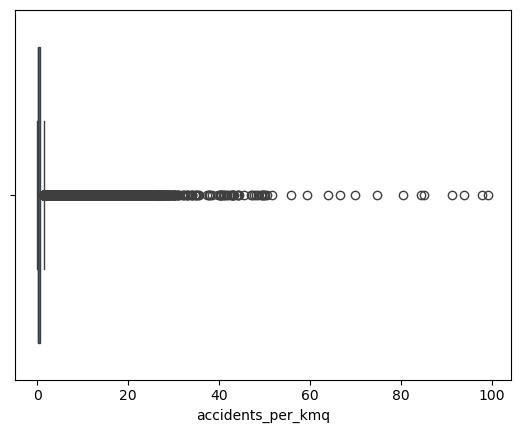

In [196]:
sns.boxplot(x = 'accidents_per_kmq', data=df_pivot)

<Axes: xlabel='accidents_per_legal_population'>

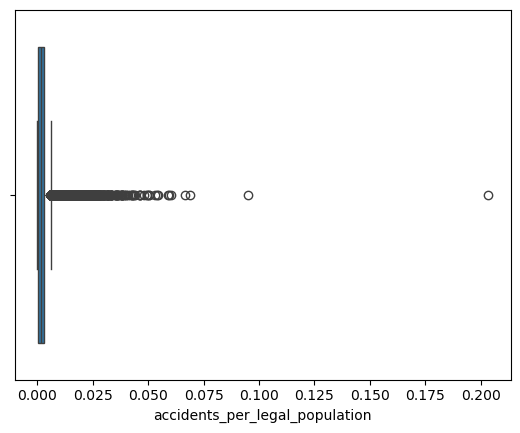

In [197]:
sns.boxplot(x = 'accidents_per_legal_population', data=df_pivot)

nel secondo box plot notiamo che ci sono dei valori che si discostano molto dal box, controlliamo come mai

In [198]:
df_pivot.sort_values('accidents_per_kmq', ascending=False).head()

,city,region_code,year,legal_population,resident_population,area_kmq,accidents,injured,fatalities,accidents_per_kmq,accidents_per_legal_population,population_density
92488,Milano,3,2001,1242123,1374582,181.6783,18026,24858,102,99.219334,0.014512,6836.936497
92489,Milano,3,2002,1242123,1374582,181.6783,17787,24487,88,97.903822,0.014320,6836.936497
92490,Milano,3,2003,1242123,1374582,181.6783,17054,22935,88,93.869218,0.013730,6836.936497
92491,Milano,3,2004,1242123,1374582,181.6783,16561,22308,79,91.155631,0.013333,6836.936497
92492,Milano,3,2005,1242123,1374582,181.6783,15443,17958,87,85.001896,0.012433,6836.936497


In [199]:
df_pivot.sort_values('accidents_per_legal_population', ascending=False).head()

,city,region_code,year,legal_population,resident_population,area_kmq,accidents,injured,fatalities,accidents_per_kmq,accidents_per_legal_population,population_density
2532,Albaredo per San Marco,3,2001,349,288,18.9604,71,83,0,3.744647,0.203438,18.406785
94823,Moncenisio,1,2022,42,41,4.5007,4,5,0,0.888751,0.095238,9.331882
172661,Vallepietra,12,2009,306,251,52.9396,21,30,0,0.396678,0.068627,5.780172
114301,Pedesina,3,2007,30,36,6.2997,2,2,0,0.317475,0.066667,4.762132
22008,Brusimpiano,3,2004,1208,1170,5.9058,73,88,0,12.360730,0.060430,204.544685


In [200]:
df_pivot.loc[df_pivot['city']== 'Albaredo per San Marco']

,city,region_code,year,legal_population,resident_population,area_kmq,accidents,injured,fatalities,accidents_per_kmq,accidents_per_legal_population,population_density
2532,Albaredo per San Marco,3,2001,349,288,18.9604,71,83,0,3.744647,0.203438,18.406785
2533,Albaredo per San Marco,3,2002,349,288,18.9604,2,2,0,0.105483,0.005731,18.406785
2534,Albaredo per San Marco,3,2003,349,288,18.9604,1,1,0,0.052742,0.002865,18.406785
2535,Albaredo per San Marco,3,2004,349,288,18.9604,3,4,0,0.158225,0.008596,18.406785
2536,Albaredo per San Marco,3,2005,349,288,18.9604,3,3,0,0.158225,0.008596,18.406785
2537,Albaredo per San Marco,3,2006,349,288,18.9604,4,5,0,0.210966,0.011461,18.406785
2538,Albaredo per San Marco,3,2007,349,288,18.9604,0,0,0,0.000000,0.000000,18.406785
2539,Albaredo per San Marco,3,2008,349,288,18.9604,0,0,0,0.000000,0.000000,18.406785
2540,Albaredo per San Marco,3,2009,349,288,18.9604,0,0,0,0.000000,0.000000,18.406785
2541,Albaredo per San Marco,3,2010,349,288,18.9604,0,0,0,0.000000,0.000000,18.406785


a questo punto, osservando tutti i dati della città Albaredo per San Marco	decidiamo di eliminare i dati relativi al 2001

In [201]:
df_pivot = df_pivot.drop(index=2532)


questo prossimo codice l'ho scritto con chatgpt

In [202]:
region_map = {
    "1": "Piemonte",
    "2": "Valle d'Aosta",
    "3": "Lombardia",
    "4": "Trentino-Alto Adige",
    "5": "Veneto",
    "6": "Friuli-Venezia Giulia",
    "7": "Liguria",
    "8": "Emilia-Romagna",
    "9": "Toscana",
    "10": "Umbria",
    "11": "Marche",
    "12": "Lazio",
    "13": "Abruzzo",
    "14": "Molise",
    "15": "Campania",
    "16": "Puglia",
    "17": "Basilicata",
    "18": "Calabria",
    "19": "Sicilia",
    "20": "Sardegna"
}

df_pivot["region_code"] = df_pivot["region_code"].astype(str)

df_pivot["region_name"] = df_pivot["region_code"].map(region_map)

creiamo un dataset con il group by per città, cosi da poter fare una cluster analysis

In [ ]:
df_group = (df_pivot.groupby("city", as_index=False).agg(
    avg_accidents_per_kmq=("accidents_per_kmq", "mean"),
    avg_accidents_per_person=("accidents_per_legal_population","mean"),
    total_injured=("injured", "sum"),
    total_fatalities=("fatalities","sum"),
    total_accidents=("accidents","sum")))
df_group.head(10)

,city,avg_accidents_per_kmq,avg_accidents_per_person,total_injured,total_fatalities,total_accidents
0,Abano Terme,2.972006,0.003288,1900,28,1527
1,Abbadia Cerreto,0.007014,0.000146,2,0,1
2,Abbadia Lariana,1.821873,0.009349,1077,12,729
3,Abbadia San Salvatore,0.196350,0.001767,406,7,278
4,Abbasanta,0.168353,0.002372,247,7,161
5,Abbateggio,0.021643,0.000756,14,0,8
6,Abbiategrasso,2.566579,0.003956,3745,38,2943
7,Abetone Cutigliano,0.051672,0.001724,44,0,31
8,Abriola,0.002237,0.000138,7,1,5
9,Acate,0.100437,0.001075,473,14,247


In [204]:
#adesso devo trasformare la colonna city nell'indice
df_group.set_index('city',inplace= True)
df_group.head()

,avg_accidents_per_kmq,avg_accidents_per_person,total_injured,total_fatalities,total_accidents
city,,,,,
Abano Terme,2.972006,0.003288,1900,28,1527
Abbadia Cerreto,0.007014,0.000146,2,0,1
Abbadia Lariana,1.821873,0.009349,1077,12,729
Abbadia San Salvatore,0.196350,0.001767,406,7,278
Abbasanta,0.168353,0.002372,247,7,161


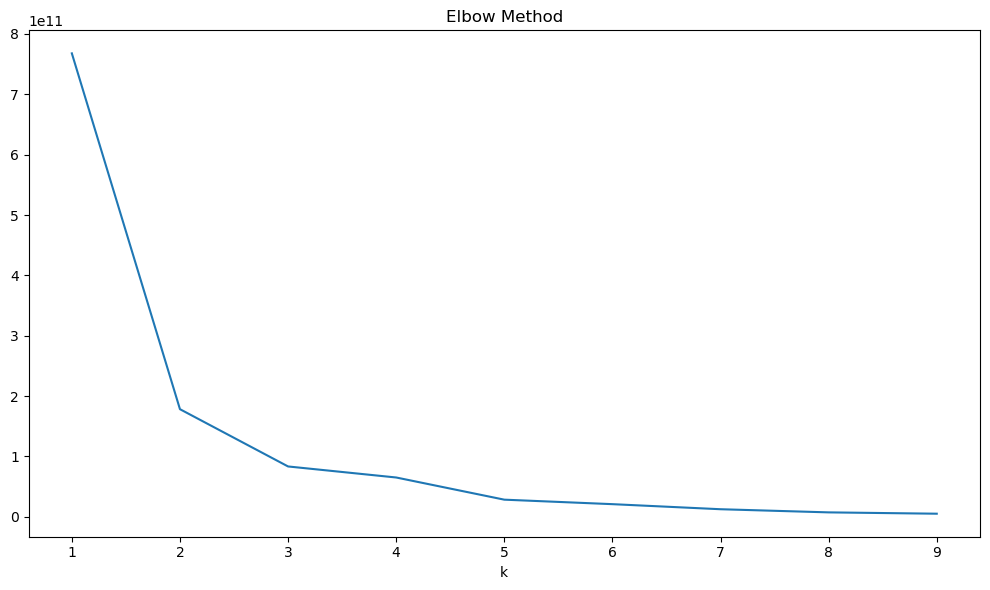

In [205]:
from sklearn.cluster import KMeans

k_values = list(range(1,10))
wcss_list = []

for k in k_values:
	kmeans = KMeans(n_clusters = k, random_state=75)
	kmeans.fit(df_group)
	wcss_list.append(kmeans.inertia_)

matplotlib.pyplot.figure(figsize=(10, 6))
matplotlib.pyplot.plot(k_values, wcss_list)
matplotlib.pyplot.title("Elbow Method")
matplotlib.pyplot.xlabel("k")
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

quindi il numero ottimale è 3.

In [206]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scale_norm = MinMaxScaler()
scaled_df = pd.DataFrame(MinMaxScaler().fit_transform(df_group), columns = df_group.columns)
#comando per normalizzare i risultati, cosi da poterli paragonare in modo più efficace


In [208]:
scaled_df.head()

,avg_accidents_per_kmq,avg_accidents_per_person,total_injured,total_fatalities,total_accidents
0,0.047547,0.147063,0.003752,0.006437,0.003909
1,0.000112,0.006547,0.000004,0.000000,0.000003
2,0.029147,0.418119,0.002127,0.002759,0.001866
3,0.003141,0.079006,0.000802,0.001609,0.000712
4,0.002693,0.106089,0.000488,0.001609,0.000412


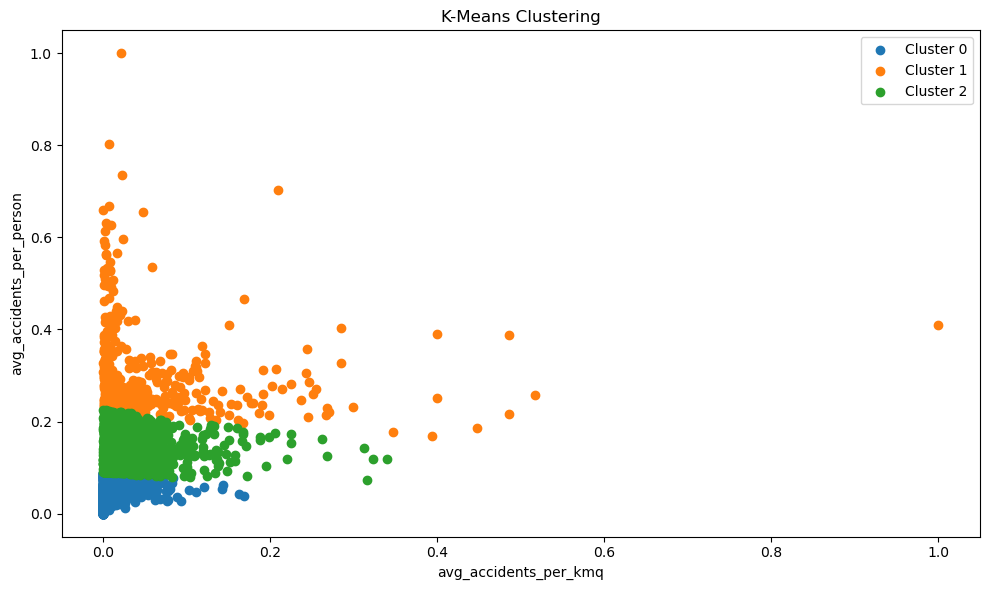

In [ ]:
# inseriamo numero di cluster e random state e fittiamo sul grafico
kmeans = KMeans(n_clusters=3, random_state=75)
kmeans.fit(scaled_df[["avg_accidents_per_kmq", "avg_accidents_per_person"]])

# con questo creiamo una colonna con il cluster assegnato per ogni città
scaled_df["cluster"] = kmeans.labels_


clusters = scaled_df.groupby("cluster")

matplotlib.pyplot.figure(figsize=(10, 6))
for cluster, data in clusters:
    matplotlib.pyplot.scatter(data["avg_accidents_per_kmq"], data["avg_accidents_per_person"], marker="o", label=f'Cluster {cluster}')

matplotlib.pyplot.xlabel("avg_accidents_per_kmq")
matplotlib.pyplot.ylabel("avg_accidents_per_person")
matplotlib.pyplot.title("K-Means Clustering")
matplotlib.pyplot.legend()
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

aggiungiamo i cluster al dataframe non normalizzato

In [225]:
df_group['clusters'] = scaled_df['cluster']

In [226]:
df_group.head()

,city,avg_accidents_per_kmq,avg_accidents_per_person,total_injured,total_fatalities,total_accidents,clusters
0,Abano Terme,2.972006,0.003288,1900,28,1527,2
1,Abbadia Cerreto,0.007014,0.000146,2,0,1,0
2,Abbadia Lariana,1.821873,0.009349,1077,12,729,1
3,Abbadia San Salvatore,0.196350,0.001767,406,7,278,0
4,Abbasanta,0.168353,0.002372,247,7,161,2


In [227]:
df_group = df_group.reset_index()

In [ ]:
cluster_summary = (df_group.groupby("clusters").agg (avg_accidents_per_kmq=("avg_accidents_per_kmq", "mean"),
        avg_accidents_per_person=("avg_accidents_per_person", "mean"),
        avg_total_fatalities=("total_fatalities", "mean"),
        avg_total_injured=("total_injured", "mean"),
        avg_total_accidents=("total_accidents", "mean"),
        n_cities=("city", "count")))
#creiamo una tabella con i dati dei singoli cluster

In [229]:
cluster_summary.head()

,avg_accidents_per_kmq,avg_accidents_per_person,avg_total_fatalities,avg_total_injured,avg_total_accidents,n_cities
clusters,,,,,,
0,0.255224,0.001025,4.528414,151.456255,99.587694,4892
1,3.584154,0.006777,67.859335,7692.887468,5782.304348,391
2,1.127846,0.002944,19.365098,1084.440873,743.773823,2613


Da questa tabella si evince che il gruppo sul quale ha sicuramente più senso investire sia il secondo cluster (cioè il n.1).
Ha tutte le metriche che abbiamo scelto più alte rispetto agli altri gruppi, ed inoltre è il gruppo con gran lunga il minor numero di osservazioni.

In [230]:
df_pivot.head()

,city,region_code,year,legal_population,resident_population,area_kmq,accidents,injured,fatalities,accidents_per_kmq,accidents_per_legal_population,population_density,region_name,accidents_per_1000_people
0,Abano Terme,5,2001,19349,20095,21.4081,79,105,0,3.690192,0.004083,903.81678,Veneto,4.082898
1,Abano Terme,5,2002,19349,20095,21.4081,86,106,1,4.017171,0.004445,903.81678,Veneto,4.444674
2,Abano Terme,5,2003,19349,20095,21.4081,57,70,1,2.662544,0.002946,903.81678,Veneto,2.945889
3,Abano Terme,5,2004,19349,20095,21.4081,63,89,0,2.942811,0.003256,903.81678,Veneto,3.255982
4,Abano Terme,5,2005,19349,20095,21.4081,81,102,4,3.783615,0.004186,903.81678,Veneto,4.186263


In [231]:
df_pivot['region_code'] = df_pivot['region_code'].astype('int')

In [232]:
df_pivot['population_density'] = df_pivot['legal_population']/df_pivot['area_kmq']

In [233]:
df_pivot['accidents_per_1000_people']= df_pivot['accidents_per_legal_population']*1000

In [234]:
df_city = df_pivot.groupby(["city"]).agg(avg_accidents_per_kmq=("accidents_per_kmq", "mean"),
        avg_accidents_per_1000_people= ("accidents_per_1000_people", "mean"),
        avg_fatalities=("fatalities", "mean"),
        avg_injured=("injured", "mean"),
        avg_accidents=("accidents", "mean"),
        region_code=("region_code","mean"),
        area_kmq= ("area_kmq", "mean"),
        population_density = ("population_density", "mean"),
        legal_population=("legal_population", "mean"))

Vediamo se c'è correlazione tra la densità di popolazione e il numero di incidenti per km quadrato

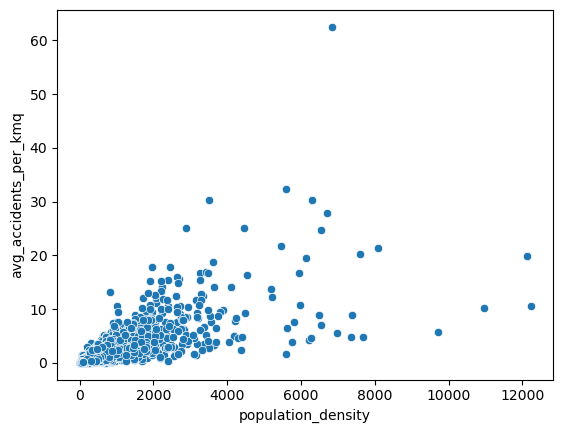

In [235]:
sns.scatterplot(x='population_density', y='avg_accidents_per_kmq', data=df_city)
plt.show()

Già dal grafico si nota esserci una correlazione tra le due variabili, calcoliamo di quanto è

In [236]:
correlation = df_city.population_density.corr(df_city.avg_accidents_per_kmq)
print(correlation)

0.768858009856703


effettuiamo un test di regressione lineare

In [237]:
Y = df_city['avg_accidents_per_kmq']
X = df_city['population_density'] #trasformiamo le variabili in x e y per semplicità
X = sm.add_constant(data=X)   #questo aggiunge una costante al modello
model = sm.OLS(endog=Y,exog=X)
results = model.fit()

In [238]:
print(results.summary())

                              OLS Regression Results                             
Dep. Variable:     avg_accidents_per_kmq   R-squared:                       0.591
Model:                               OLS   Adj. R-squared:                  0.591
Method:                    Least Squares   F-statistic:                 1.141e+04
Date:                   Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                           15:28:06   Log-Likelihood:                -12855.
No. Observations:                   7896   AIC:                         2.571e+04
Df Residuals:                       7894   BIC:                         2.573e+04
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const 

da questa tabella si evince che la relazione tra le due variabili sia veritiera, lo si capisce grazie al valore del p value che è molto basso.

In [241]:
df_city.head()

,city,avg_accidents_per_kmq,avg_accidents_per_1000_people,avg_fatalities,avg_injured,avg_accidents,region_code,area_kmq,population_density,legal_population
0,Abano Terme,2.972006,3.288284,1.166667,79.166667,63.625000,5.0,21.4081,903.816780,19349.0
1,Abbadia Cerreto,0.007014,0.146391,0.000000,0.086957,0.043478,3.0,6.1986,47.914045,297.0
2,Abbadia Lariana,1.821873,9.349030,0.500000,44.875000,30.375000,3.0,16.6724,194.872964,3249.0
3,Abbadia San Salvatore,0.196350,1.766560,0.291667,16.916667,11.583333,9.0,58.9933,111.148215,6557.0
4,Abbasanta,0.168353,2.372112,0.291667,10.291667,6.708333,20.0,39.8469,70.971644,2828.0


In [240]:
df_city = df_city.reset_index()

In [ ]:
df_pivot.to_csv('new_df.csv')
#ci salviamo il file per usarlo poi su power bi